In [1]:
!nvidia-smi

Mon Mar  2 14:53:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install cudf-cu11 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 54.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 445.9/445.9 MB 21.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 194.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.7/27.7 MB 62.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 172.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 MB 59.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 177.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.5/275.5 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.7/99.7 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 577.0/577.0 kB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.

In [1]:
!nvidia-smi

Mon Mar  2 14:59:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install cudf-cu11 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com


In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [2]:
import cudf
print("cuDF version:", cudf.__version__)

cuDF version: 26.02.01


In [3]:
def generate_dataset(n):
    np.random.seed(42)
    df = pd.DataFrame({
        'customer_id': np.random.randint(1, 100000, n),
        'transaction_amount': np.random.uniform(10, 10000, n),
        'category': np.random.choice(['retail', 'finance', 'healthcare', 'tech'], n),
        'region': np.random.choice(['north', 'south', 'east', 'west'], n),
        'timestamp': pd.date_range('2020-01-01', periods=n, freq='s')
    })
    return df

print("Generator defined")

Generator defined


In [4]:
def run_pandas_pipeline(df):
    # Step 1: Filter
    filtered = df[df['transaction_amount'] > 500]
    # Step 2: Feature engineering
    filtered = filtered.copy()
    filtered['high_value'] = filtered['transaction_amount'] > 5000
    # Step 3: Group and aggregate
    grouped = filtered.groupby(['category', 'region'])['transaction_amount'].agg(['mean', 'sum', 'count'])
    # Step 4: Sort
    result = grouped.sort_values('sum', ascending=False)
    return result

def run_cudf_pipeline(df):
    # Exact same operations, cuDF mirrors Pandas API
    filtered = df[df['transaction_amount'] > 500]
    filtered = filtered.copy()
    filtered['high_value'] = filtered['transaction_amount'] > 5000
    grouped = filtered.groupby(['category', 'region'])['transaction_amount'].agg(['mean', 'sum', 'count'])
    result = grouped.sort_values('sum', ascending=False)
    return result

print("Pipelines defined")

Pipelines defined


In [5]:
sizes = [1_000_000, 5_000_000, 10_000_000]
size_labels = ['1M', '5M', '10M']

pandas_times = []
cudf_times = []
speedups = []

for n, label in zip(sizes, size_labels):
    print(f"\n{'='*40}")
    print(f"Running benchmark at {label} rows...")
    print(f"{'='*40}")

    # Generate Pandas DataFrame
    df_pandas = generate_dataset(n)

    # --- Pandas Benchmark ---
    # Warm-up run
    _ = run_pandas_pipeline(df_pandas)
    # Timed run
    start = time.time()
    pandas_result = run_pandas_pipeline(df_pandas)
    pandas_time = round(time.time() - start, 3)
    pandas_times.append(pandas_time)
    print(f"  Pandas time   : {pandas_time}s")

    # --- cuDF Benchmark ---
    # Convert to GPU DataFrame
    df_gpu = cudf.from_pandas(df_pandas)
    # Warm-up run (GPU needs to warm up on first call)
    _ = run_cudf_pipeline(df_gpu)
    # Timed run
    start = time.time()
    cudf_result = run_cudf_pipeline(df_gpu)
    cudf_time = round(time.time() - start, 3)
    cudf_times.append(cudf_time)
    print(f"  cuDF time     : {cudf_time}s")

    # Speedup
    speedup = round(pandas_time / cudf_time, 1)
    speedups.append(speedup)
    print(f"  Speedup       : {speedup}x faster with cuDF")

    # Free GPU memory between runs
    del df_gpu
    del df_pandas

print("\n✅ Benchmark complete!")


Running benchmark at 1M rows...
  Pandas time   : 1.044s
  cuDF time     : 0.087s
  Speedup       : 12.0x faster with cuDF

Running benchmark at 5M rows...
  Pandas time   : 1.492s
  cuDF time     : 0.059s
  Speedup       : 25.3x faster with cuDF

Running benchmark at 10M rows...
  Pandas time   : 3.032s
  cuDF time     : 0.087s
  Speedup       : 34.9x faster with cuDF

✅ Benchmark complete!


In [6]:
print("\n" + "="*50)
print(f"{'Dataset Size':<15} {'Pandas (s)':<15} {'cuDF (s)':<15} {'Speedup':<10}")
print("="*50)
for label, p, c, s in zip(size_labels, pandas_times, cudf_times, speedups):
    print(f"{label:<15} {p:<15} {c:<15} {s}x")
print("="*50)


Dataset Size    Pandas (s)      cuDF (s)        Speedup   
1M              1.044           0.087           12.0x
5M              1.492           0.059           25.3x
10M             3.032           0.087           34.9x


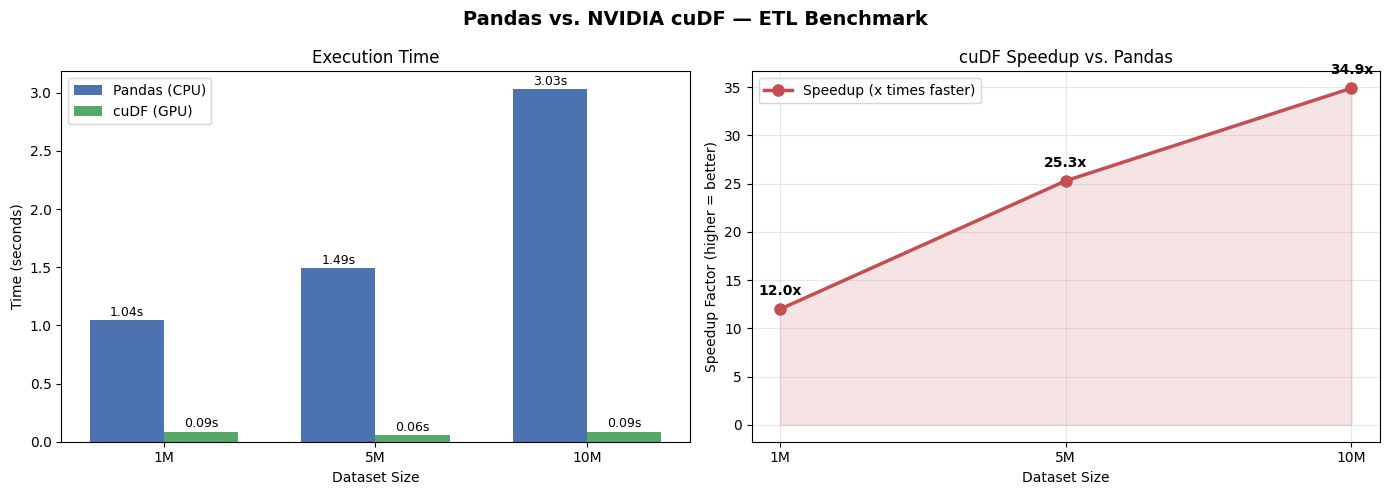

Chart saved as benchmark_results.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pandas vs. NVIDIA cuDF — ETL Benchmark', fontsize=14, fontweight='bold')

# Chart 1: Execution time comparison
x = np.arange(len(size_labels))
width = 0.35
bars1 = axes[0].bar(x - width/2, pandas_times, width, label='Pandas (CPU)', color='#4C72B0')
bars2 = axes[0].bar(x + width/2, cudf_times, width, label='cuDF (GPU)', color='#55A868')
axes[0].set_xlabel('Dataset Size')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Execution Time')
axes[0].set_xticks(x)
axes[0].set_xticklabels(size_labels)
axes[0].legend()
# Add value labels on bars
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}s', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}s', ha='center', va='bottom', fontsize=9)

# Chart 2: Speedup factor
axes[1].plot(size_labels, speedups, marker='o', linewidth=2.5,
             color='#C44E52', markersize=8, label='Speedup (x times faster)')
axes[1].fill_between(range(len(size_labels)), speedups, alpha=0.15, color='#C44E52')
for i, (label, s) in enumerate(zip(size_labels, speedups)):
    axes[1].annotate(f'{s}x', (i, s), textcoords="offset points",
                     xytext=(0, 10), ha='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Dataset Size')
axes[1].set_ylabel('Speedup Factor (higher = better)')
axes[1].set_title('cuDF Speedup vs. Pandas')
axes[1].set_xticks(range(len(size_labels)))
axes[1].set_xticklabels(size_labels)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as benchmark_results.png")

In [8]:
results_df = pd.DataFrame({
    'Dataset Size': size_labels,
    'Pandas Time (s)': pandas_times,
    'cuDF Time (s)': cudf_times,
    'Speedup': speedups
})

results_df.to_csv('benchmark_results.csv', index=False)
print(results_df.to_string(index=False))
print("\nResults saved to benchmark_results.csv")

Dataset Size  Pandas Time (s)  cuDF Time (s)  Speedup
          1M            1.044          0.087     12.0
          5M            1.492          0.059     25.3
         10M            3.032          0.087     34.9

Results saved to benchmark_results.csv
